# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
# Manipulasi dan Analisis Data
import pandas as pd
import numpy as np

# Visualisasi Data
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing dan Modeling (Scikit-Learn)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Opsional: Jika menggunakan Deep Learning
# import tensorflow as tf
# from tensorflow import keras


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("muamkh/ihsgstockdata")

print("Path to dataset files:", path)

100%|██████████| 328M/328M [00:02<00:00, 161MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/muamkh/ihsgstockdata/versions/42


In [3]:
import os

# Melihat daftar file di dalam folder yang diunduh
files = os.listdir(path)
print("Isi folder dataset:", files)

Isi folder dataset: ['hourly', 'DaftarSaham.csv', 'daily', 'minutes']


In [4]:
import pandas as pd

# Contoh: Membaca file pertama dalam folder jika formatnya CSV
file_csv = [f for f in files if f.endswith('.csv')][0]
full_path = os.path.join(path, file_csv)

df = pd.read_csv(full_path)
df.head()

,Code,Name,ListingDate,Shares,ListingBoard,Sector,LastPrice,MarketCap,MinutesFirstAdded,MinutesLastUpdated,HourlyFirstAdded,HourlyLastUpdated,DailyFirstAdded,DailyLastUpdated
0,AALI,Astra Agro Lestari Tbk.,1997-12-09,1.924688e+09,Utama,Consumer Non-Cyclicals,8000.0,1.539751e+13,2021-11-01 09:00:00,2023-01-06 15:59:00,2020-04-16 09:00:00,2023-01-06 15:00:00,2001-04-16,2023-01-06
1,ABBA,Mahaka Media Tbk.,2002-04-03,3.935893e+09,Pengembangan,Consumer Cyclicals,142.0,5.588968e+11,2021-11-01 09:00:00,2023-01-06 15:59:00,2020-04-16 09:00:00,2023-01-06 15:00:00,2002-04-03,2023-01-06
2,ABDA,Asuransi Bina Dana Arta Tbk.,1989-07-06,6.208067e+08,Pengembangan,Financials,6700.0,4.159405e+12,2021-11-01 09:00:00,2022-11-11 15:59:00,2020-04-16 09:00:00,2022-11-11 16:00:00,2001-04-16,2023-01-06
3,ABMM,ABM Investama Tbk.,2011-12-06,2.753165e+09,Utama,Industrials,3050.0,8.397153e+12,2021-11-01 09:00:00,2023-01-06 15:59:00,2020-04-16 09:00:00,2023-01-06 15:00:00,2011-12-06,2023-01-06
4,ACES,Ace Hardware Indonesia Tbk.,2007-11-06,1.715000e+10,Utama,Consumer Cyclicals,490.0,8.403500e+12,2021-11-01 09:00:00,2023-01-06 15:59:00,2020-04-16 09:00:00,2023-01-06 15:00:00,2007-11-06,2023-01-06


In [5]:
def load_kaggle_data(dataset_handle):
    """
    Fungsi otomatis untuk mengunduh dan memuat dataset dari Kaggle.
    """
    import kagglehub
    import pandas as pd
    import os

    # Download
    data_dir = kagglehub.dataset_download(dataset_handle)

    # Ambil file CSV pertama yang ditemukan
    files = os.listdir(data_dir)
    csv_files = [f for f in files if f.endswith('.csv')]

    if not csv_files:
        raise FileNotFoundError("Tidak ada file CSV di dataset ini.")

    df = pd.read_csv(os.path.join(data_dir, csv_files[0]))
    return df

# Penggunaan otomatis
df_ihsg = load_kaggle_data("muamkh/ihsgstockdata")

# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 829 entries, 0 to 828
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Code                829 non-null    object 
 1   Name                829 non-null    object 
 2   ListingDate         829 non-null    object 
 3   Shares              829 non-null    float64
 4   ListingBoard        829 non-null    object 
 5   Sector              829 non-null    object 
 6   LastPrice           824 non-null    float64
 7   MarketCap           824 non-null    float64
 8   MinutesFirstAdded   787 non-null    object 
 9   MinutesLastUpdated  787 non-null    object 
 10  HourlyFirstAdded    806 non-null    object 
 11  HourlyLastUpdated   806 non-null    object 
 12  DailyFirstAdded     824 non-null    object 
 13  DailyLastUpdated    824 non-null    object 
dtypes: float64(3), object(11)
memory usage: 90.8+ KB


In [7]:
df.describe()

,Shares,LastPrice,MarketCap
count,8.290000e+02,824.000000,8.240000e+02
mean,1.094694e+10,1363.453883,1.007663e+13
std,4.539593e+10,3733.432446,5.053142e+13
min,3.600000e+06,25.000000,9.000000e+09
25%,1.230840e+09,101.750000,2.975283e+11
50%,3.128090e+09,287.000000,1.111305e+12
75%,9.327465e+09,975.000000,4.236953e+12
max,1.184364e+12,38000.000000,1.012951e+15


In [8]:
df.isnull().sum()

,0
Code,0
Name,0
ListingDate,0
Shares,0
ListingBoard,0
Sector,0
LastPrice,5
MarketCap,5
MinutesFirstAdded,42
MinutesLastUpdated,42


In [22]:
print("Shape:", df.shape)

Shape: (829, 17)


<Axes: >

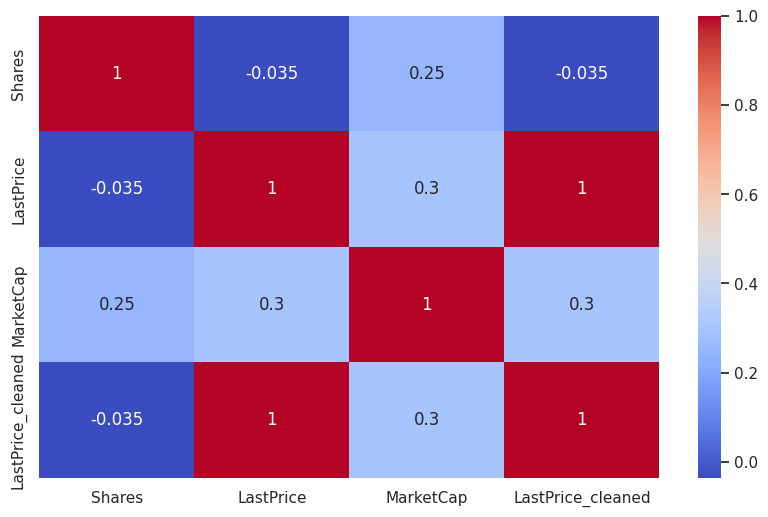

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

<Axes: >

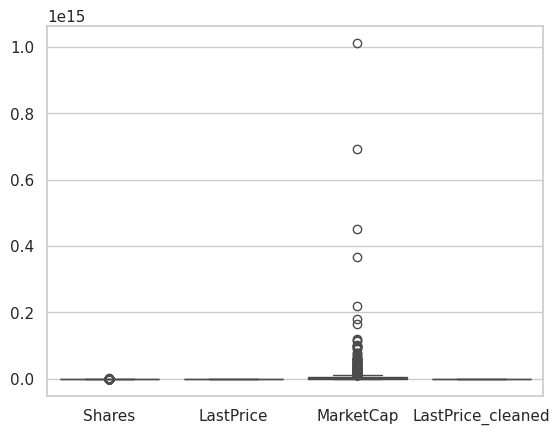

In [29]:
sns.boxplot(data=df)

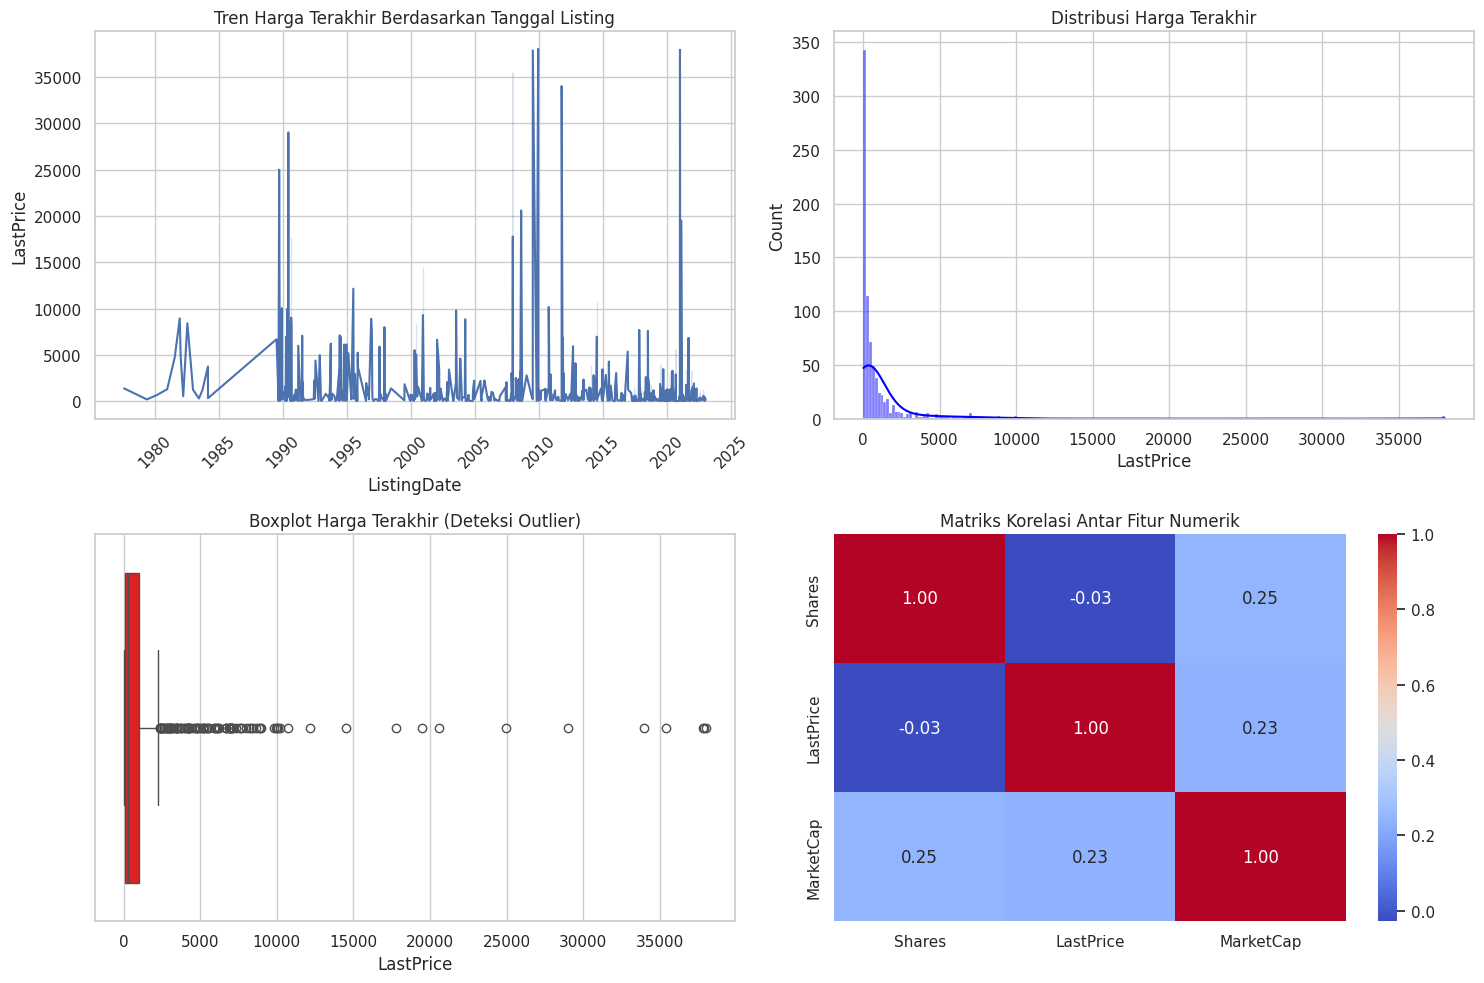

In [9]:
# Pengaturan Visualisasi
sns.set(style="whitegrid")
plt.figure(figsize=(15, 10))

# 4. Visualisasi Tren Harga (Time-Series)
# Pastikan kolom tanggal bertipe datetime dan tersedia
if 'ListingDate' in df.columns and 'LastPrice' in df.columns:
    df_sorted = df.sort_values(by='ListingDate') # Sort by ListingDate for a more meaningful trend, if we plot all points.
    # Use format='mixed' to handle potential inconsistencies in date string formats
    df_sorted['ListingDate'] = pd.to_datetime(df_sorted['ListingDate'], format='mixed', dayfirst=False)
    plt.subplot(2, 2, 1)
    # This plot would show the LastPrice of companies ordered by their listing date, not a true time-series of a single stock.
    # A true time-series would require daily/hourly price data for a single stock or index.
    sns.lineplot(data=df_sorted, x='ListingDate', y='LastPrice')
    plt.title('Tren Harga Terakhir Berdasarkan Tanggal Listing') # Adjusted title
    plt.xticks(rotation=45)
else:
    plt.subplot(2, 2, 1)
    plt.text(0.5, 0.5, 'Tidak dapat membuat Visualisasi Tren Harga:\nKolom "ListingDate" atau "LastPrice" tidak ditemukan',
             horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes)
    plt.title('Visualisasi Tren Harga (Tidak Tersedia)')


# 5. Visualisasi Distribusi (Histogram)
plt.subplot(2, 2, 2)
if 'LastPrice' in df.columns:
    sns.histplot(df['LastPrice'].dropna(), kde=True, color='blue') # Added .dropna() to handle NaNs in LastPrice
    plt.title('Distribusi Harga Terakhir') # Adjusted title
else:
    plt.text(0.5, 0.5, 'Tidak dapat membuat Visualisasi Distribusi:\nKolom "LastPrice" tidak ditemukan',
             horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes)
    plt.title('Visualisasi Distribusi (Tidak Tersedia)')


# 6. Deteksi Outliers (Boxplot)
plt.subplot(2, 2, 3)
if 'LastPrice' in df.columns:
    sns.boxplot(x=df['LastPrice'].dropna(), color='red') # Added .dropna()
    plt.title('Boxplot Harga Terakhir (Deteksi Outlier)') # Adjusted title
else:
    plt.text(0.5, 0.5, 'Tidak dapat membuat Deteksi Outliers:\nKolom "LastPrice" tidak ditemukan',
             horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes)
    plt.title('Deteksi Outliers (Tidak Tersedia)')


# 7. Heatmap Korelasi
plt.subplot(2, 2, 4)
numeric_df = df.select_dtypes(include=[np.number])
if not numeric_df.empty and len(numeric_df.columns) > 1: # Ensure there are at least two numeric columns for correlation
    sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Matriks Korelasi Antar Fitur Numerik') # Adjusted title
else:
    plt.text(0.5, 0.5, 'Tidak dapat membuat Heatmap Korelasi:\nTidak cukup kolom numerik untuk korelasi',
             horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes)
    plt.title('Heatmap Korelasi (Tidak Tersedia)')

plt.tight_layout()
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [32]:
# Cek data kosong
print(df.isnull().sum())

# Mengisi missing values dengan harga terakhir yang tersedia
df = df.fillna(method='ffill')

Code                  0
Name                  0
ListingDate           0
Shares                0
ListingBoard          0
Sector                0
LastPrice             0
MarketCap             0
MinutesFirstAdded     0
MinutesLastUpdated    0
HourlyFirstAdded      0
HourlyLastUpdated     0
DailyFirstAdded       0
DailyLastUpdated      0
LastPrice_cleaned     0
price_category        0
price_quantile        0
dtype: int64


/tmp/ipykernel_7499/2642644811.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


In [31]:
df = df.drop_duplicates()

In [33]:
df = pd.get_dummies(df, drop_first=True)

In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)
df = pd.DataFrame(df_scaled, columns=df.columns)

In [39]:
from sklearn.feature_selection import SelectKBest, f_classif
import pandas as pd # Ensure pandas is imported for pd.cut

# Re-create 'price_category' if it's missing due to prior transformations.
# This assumes 'LastPrice' column is available and appropriately preprocessed for categorization.
# Note: 'LastPrice' would be scaled at this point from previous steps.
if 'price_category' not in df.columns:
    df['price_category'] = pd.cut(df['LastPrice'], bins=3, labels=['Low', 'Medium', 'High'])

# Define the target variable (y) and features (X)
# Assuming 'price_category' is the target for classification
y = df['price_category']

# Define columns to potentially drop, and filter to only include those that exist in df
cols_to_drop = ['price_category', 'price_quantile', 'LastPrice', 'LastPrice_cleaned']
existing_cols_to_drop = [col for col in cols_to_drop if col in df.columns]

X = df.drop(columns=existing_cols_to_drop)

# Ensure X only contains numerical features for f_classif
# After get_dummies and StandardScaler, X should already be numeric.
X_numeric = X.select_dtypes(include=[np.number]) # Corrected line: removed pd.Number

# Check for NaNs in X_numeric, as f_classif cannot handle them. Impute if necessary.
# Given previous fillna and scaling, NaNs should be minimal, but a check is good practice.
X_numeric = X_numeric.fillna(X_numeric.mean())

selector = SelectKBest(score_func=f_classif, k=5)
df_selected = selector.fit_transform(X_numeric, y)

In [ ]:
from preprocessing.automate_Nico import scaling


def preprocess(df):
    df = handle_missing(df)
    df = encoding(df)
    df = scaling(df)
    return df

In [12]:
# Menggunakan IQR untuk mendeteksi outlier pada kolom 'LastPrice'
Q1 = df['LastPrice'].quantile(0.25)
Q3 = df['LastPrice'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Opsi: Clipping (membatasi nilai agar tetap di range bound)
df['LastPrice'] = df['LastPrice'].clip(lower=lower_bound, upper=upper_bound)

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
# Hanya kolom numerik yang discaling
df[['LastPrice']] = scaler.fit_transform(df[['LastPrice']])

In [14]:
# Jika hanya ada beberapa kategori, gunakan LabelEncoder
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
if 'ticker' in df.columns:
    df['ticker_encoded'] = le.fit_transform(df['ticker'])

In [15]:
def automated_preprocessing(df):
    """
    Fungsi tunggal untuk membersihkan data IHSG secara otomatis.
    """
    # 1. Konversi Tanggal
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df = df.sort_values('date')

    # 2. Tangani Missing Values & Duplikat
    df = df.drop_duplicates()
    df = df.fillna(method='ffill')

    # 3. Feature Engineering (Contoh: Menambah Moving Average)
    df['MA5'] = df['close'].rolling(window=5).mean()

    # 4. Scaling (Opsional tergantung model)
    # ... code scaling ...

    return df.dropna() # Menghapus baris awal yang kosong akibat rolling MA

In [16]:
import numpy as np

def detect_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

    print(f"Batas Bawah: {lower_bound}")
    print(f"Batas Atas: {upper_bound}")
    print(f"Total Outlier ditemukan: {len(outliers)}")

    return outliers, lower_bound, upper_bound

# Jalankan deteksi
outliers, lb, ub = detect_outliers(df, 'LastPrice')

Batas Bawah: -2.4497725002450355
Batas Atas: 2.0989061293197504
Total Outlier ditemukan: 0


In [17]:
# Menerapkan Capping (Winsorization)
# Nilai di atas batas atas akan menjadi batas atas, di bawah batas bawah menjadi batas bawah
df['LastPrice_cleaned'] = df['LastPrice'].clip(lower=lb, upper=ub)

# Bandingkan ringkasan statistiknya
print(df[['LastPrice', 'LastPrice_cleaned']].describe())

          LastPrice  LastPrice_cleaned
count  8.290000e+02       8.290000e+02
mean  -5.356927e-17      -5.356927e-17
std    1.000604e+00       1.000604e+00
min   -8.429023e-01      -8.429023e-01
25%   -7.440180e-01      -7.440180e-01
50%   -5.033128e-01      -5.033128e-01
75%    3.931516e-01       3.931516e-01
max    2.098906e+00       2.098906e+00


In [18]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
import pandas as pd

# Contoh Data
data = {'Sektor': ['Finansial', 'Energi', 'Properti', 'Finansial'],
        'Risk_Level': ['Low', 'High', 'Medium', 'Low']}
df_sample = pd.DataFrame(data)

# 1. Label Encoding untuk Risk_Level (Karena ada urutan)
le = LabelEncoder()
df_sample['Risk_Level_Encoded'] = le.fit_transform(df_sample['Risk_Level'])

# 2. One-Hot Encoding untuk Sektor (Tidak ada urutan)
# Menggunakan pandas get_dummies agar lebih cepat
df_sector_ohe = pd.get_dummies(df_sample['Sektor'], prefix='Sektor')

# Gabungkan kembali ke dataframe utama
df_final = pd.concat([df_sample, df_sector_ohe], axis=1)

display(df_final)

,Sektor,Risk_Level,Risk_Level_Encoded,Sektor_Energi,Sektor_Finansial,Sektor_Properti
0,Finansial,Low,1,False,True,False
1,Energi,High,0,True,False,False
2,Properti,Medium,2,False,False,True
3,Finansial,Low,1,False,True,False


In [19]:
# Membagi harga saham menjadi 3 kategori: Low, Medium, High
df['price_category'] = pd.cut(df['LastPrice'], bins=3, labels=['Low', 'Medium', 'High'])

print(df[['LastPrice', 'price_category']].head())

   LastPrice price_category
0   2.098906           High
1  -0.690673            Low
2   2.098906           High
3   2.098906           High
4  -0.237886            Low


In [20]:
# Membagi data menjadi 4 bagian (Quartile) dengan jumlah data yang sama di tiap bin
df['price_quantile'] = pd.qcut(df['LastPrice'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])

print(df['price_quantile'].value_counts())

price_quantile
Q1    208
Q3    208
Q2    207
Q4    206
Name: count, dtype: int64
